# Окружение

In [247]:
import json
import os

import matplotlib.pyplot as plt
import mlflow
from mlflow.models import infer_signature, evaluate
import mlflow.sklearn
import mlflow.shap
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [246]:
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

In [104]:
pd.options.display.max_columns = 200
pd.options.display.max_rows = 64 

# Загрузка датасетов

In [42]:
dr_dataset = pd.read_csv("data/DR_test.csv", encoding="cp1251", )
macro_dataset = pd.read_excel("data/macro.xlsx", header=[1], )


# EDA

In [8]:
dr_dataset

,segment_merged,01.04.2015,01.05.2015,01.06.2015,01.07.2015,01.08.2015,01.09.2015,01.10.2015,01.11.2015,01.12.2015,...,01.03.2021,01.04.2021,01.05.2021,01.06.2021,01.07.2021,01.08.2021,01.09.2021,01.10.2021,01.11.2021,01.12.2021
0,сегмент1,0.108414,0.101925,0.09306,0.082731,0.074459,0.069345,0.066409,0.063881,0.060677,...,0.059302,0.060284,0.059411,0.057704,0.05889,0.057608,0.056394,0.059483,0.060864,0.062735


In [108]:
dr_transposed = dr_dataset.set_index('segment_merged').T
dr_transposed.describe()

segment_merged,сегмент1
count,81.000000
mean,0.060871
std,0.013878
min,0.041339
25%,0.050076
50%,0.058890
75%,0.063881
max,0.108414


In [153]:
def group_to_quarters(df):
    # 1. Сохраняем сегменты отдельно, чтобы они не мешали расчетам
    df = df.set_index("segment_merged")

    # 2. Транспонируем, чтобы даты стали индексом (строками)
    df_t = df.T

    # 3. Превращаем индекс в формат datetime
    # dayfirst=True, так как у вас формат 01.04.2015 (день на первом месте)
    df_t.index = pd.to_datetime(df_t.index, dayfirst=True)

    # 4. Группируем по кварталам ('Q') и считаем среднее (mean)
    # Можно заменить .mean() на .sum(), если нужны суммы
    df_quarterly = df_t.resample("Q").mean()

    # 5. Форматируем индекс в вид "Q2-2015"
    # to_period('Q') превращает дату в квартал, strftime форматирует в строку
    df_quarterly.index = df_quarterly.index.to_period("Q").strftime("Q%q-%Y")

    df_quarterly = (
        df_quarterly.rename_axis("quarter")
        .reset_index()
        .rename_axis(None, axis=1)  # убирает 'segment_merged' с оси колонок
    )

    df_quarterly = df_quarterly.rename(columns={"сегмент1": "default_probability"})

    return df_quarterly


# Применение:
dr_quarterly = group_to_quarters(dr_dataset)
dr_quarterly

C:\Users\Салтанат\AppData\Local\Temp\ipykernel_13360\1087615699.py:14: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_quarterly = df_t.resample("Q").mean()


,quarter,default_probability
0,Q2-2015,0.101133
1,Q3-2015,0.075512
2,Q4-2015,0.063656
3,Q1-2016,0.054744
4,Q2-2016,0.048866
5,Q3-2016,0.049003
6,Q4-2016,0.048119
7,Q1-2017,0.048732
8,Q2-2017,0.045878
9,Q3-2017,0.047653


In [106]:
macro_dataset

,Наименование показателя,Единица измерения,Техническое название показателя,Q1-2010,Q2-2010,Q3-2010,Q4-2010,Q1-2011,Q2-2011,Q3-2011,Q4-2011,Q1-2012,Q2-2012,Q3-2012,Q4-2012,Q1-2013,Q2-2013,Q3-2013,Q4-2013,Q1-2014,Q2-2014,Q3-2014,Q4-2014,Q1-2015,Q2-2015,Q3-2015,Q4-2015,Q1-2016,Q2-2016,Q3-2016,Q4-2016,Q1-2017,Q2-2017,Q3-2017,Q4-2017,Q1-2018,Q2-2018,Q3-2018,Q4-2018,Q1-2019,Q2-2019,Q3-2019,Q4-2019,Q1-2020,Q2-2020,Q3-2020,Q4-2020,Q1-2021,Q2-2021,Q3-2021,Q4-2021,Q1-2022,Q2-2022,Q3-2022,Q4-2022
0,TONIA,units,macroparameter,Q-47,Q-46,Q-45,Q-44,Q-43,Q-42,Q-41,Q-40,Q-39,Q-38,Q-37,Q-36,Q-35,Q-34,Q-33,Q-32,Q-31,Q-30,Q-29,Q-28,Q-27,Q-26,Q-25,Q-24,Q-23,Q-22,Q-21,Q-20,Q-19,Q-18,Q-17,Q-16,Q-15,Q-14,Q-13,Q-12,Q-11,Q-10,Q-9,Q-8,Q-7,Q-6,Q-5,Q-4,Q-3,Q-2,Q-1,Q0,Q1,Q2,Q3,Q4
1,Реальный ВВП,"млрд. тенге, в ценах базисного 2005 года",real_gdp,2434.8701,2506.4103,2512.3491,2816.4435,2582.0281,2714.742,2689.9273,3019.6632,2763.2092,2886.1425,2770.3329,3140.7893,2881.079,3051.7461,2958.3537,3360.0391,3000.3438,3170.1096,3074.8071,3522.1178,3060.2427,3214.0682,3083.6996,3561.1796,3059.0323,3223.2459,3099.8356,3681.2976,3171.3149,3380.5208,3228.9492,3821.5587,3307.7708,3519.4857,3352.7264,3976.474,3430.8583,3674.1333,3518.8788,4170.1963,3509.1853,3446.9462,3333.6353,4132.3609,3464.5067,3684.5208,3556.8014,4338.7274,3573.6895,3771.002284,3660.974893,4460.1372
2,Реальная валовая добавленная стоимость 'Сельск...,"млрд. тенге, в ценах базисного 2005 года",GDD_Agr_R,136.0547,138.7062,115.6584,124.1525,134.4387,136.2578,149.8782,212.8609,127.1747,126.222,131.0491,136.1939,127.4974,128.7908,148.3691,173.702,131.1646,131.9779,146.211,175.1419,134.4915,134.7847,150.4386,183.095,137.6255,137.4111,162.9543,195.6634,141.2366,141.5582,163.141,208.369,145.9906,148.031,160.6379,224.2804,151.3116,153.1174,148.4765,225.657,153.3979,154.3253,162.6258,240.3885,156.5923,158.4558,158.5567,216.6447,157.3956,160.194981,174.742473,233.829293
3,Реальная валовая добавленная стоимость 'Горно...,"млрд. тенге, в ценах базисного 2005 года",GDD_Min_R,402.1685,405.1253,348.4932,455.9193,409.5705,407.0741,331.1333,433.9211,406.4699,403.1677,323.7088,449.0039,419.1677,408.4633,342.2568,465.0578,414.0357,406.6769,345.1902,466.6919,417.7452,410.4074,318.1139,439.4326,410.6594,389.4052,294.7044,451.2817,435.5286,443.4692,341.3653,473.5758,457.9723,469.8433,353.0003,490.2392,477.4853,465.7908,371.8937,505.002,495.8756,457.6078,317.3827,457.3856,457.9454,460.478,333.4763,496.8967,438.6169,451.844389,354.162423,512.136355
4,Реальная валовая добавленная стоимость 'Обраба...,"млрд. тенге, в ценах базисного 2005 года",GDD_Man_R,243.9381,272.0196,241.065,278.4155,258.9057,286.1791,259.1077,277.593,280.9727,296.235,241.1393,292.0135,282.9606,299.6511,239.009,319.012,276.4303,296.2188,244.554,338.9154,275.807,298.5757,251.9981,327.7011,275.8458,299.7437,253.3333,342.4596,296.1866,318.9393,264.0197,364.4005,313.8424,331.779,277.1157,376.2226,319.0871,346.9273,287.8559,417.1963,343.3693,347.6378,284.5063,434.7989,366.5457,357.3785,299.9966,442.3699,385.4358,375.356096,313.347532,462.322539
5,Реальная валовая добавленная стоимость 'Электр...,"млрд. тенге, в ценах базисного 2005 года",GDD_Elc_R,41.9814,41.8145,42.2506,43.0749,43.3606,43.6802,44.7569,47.2298,46.5119,45.8863,44.8304,47.8924,45.5255,47.1749,45.8178,47.9646,46.1544,47.8265,46.7339,50.2454,45.0324,47.1689,45.6151,49.4996,44.5689,46.609,46.4374,50.0791,46.2799,49.6607,49.026,53.1547,48.1911,52.7848,49.8234,51.8556,48.583,55.9864,52.8335,49.3661,47.5223,58.4882,52.0052,46.2871,49.5032,61.5578,55.4239,48.3618,48.5352,61.541464,56.438517,49.595347
6,Реальная валовая добавленная стоимость 'Строит...,"млрд. тенге, в ценах базисного 2005 года",GDD_Con_R,273.2341,272.9059,283.9541,286.0324,273.6952,265.9681,290.3467,284.9051,270.8015,269.5972,305.6768,299.4016,257.0067,286.2605,322.5121,317.8086,266.4123,298.2838,336.1978,334.3021,270.4259,320.9093,346.7065,346.8299,285.9224,342.762,371.2654,376.1359,306.4046,359.7372,369.3047,379.8111,324.368,366.7801,

In [44]:
macro_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 55 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Наименование показателя          60 non-null     object
 1   Единица измерения                60 non-null     object
 2   Техническое название показателя  60 non-null     object
 3   Q1-2010                          55 non-null     object
 4   Q2-2010                          55 non-null     object
 5   Q3-2010                          55 non-null     object
 6   Q4-2010                          55 non-null     object
 7   Q1-2011                          55 non-null     object
 8   Q2-2011                          55 non-null     object
 9   Q3-2011                          55 non-null     object
 10  Q4-2011                          55 non-null     object
 11  Q1-2012                          56 non-null     object
 12  Q2-2012                          56 no

In [163]:
macro_dataset_transposed = (
    macro_dataset
    .set_index('Техническое название показателя')
    .iloc[:, 2:]
    .T
    .rename_axis('quarter')
    .reset_index()
    .rename_axis(None, axis=1)
)
macro_dataset_transposed.head()

,quarter,macroparameter,real_gdp,GDD_Agr_R,GDD_Min_R,GDD_Man_R,GDD_Elc_R,GDD_Con_R,GDD_Trd_R,GDD_Trn_R,GDD_Inf_R,GDD_Fin_R,GDD_Est_R,GDD_Oth_R,GDD_R,GDP_DEF,Rincpop_q,Rexppop_q,Rwage_q,imp,exp,cpi,realest_resed_prim,realest_resed_sec,realest_comm,index_stock_weighted,ntrade_Agr,ntrade_Min,ntrade_Man,ntrade_Elc,ntrade_Con,ntrade_Trd,ntrade_Trn,ntrade_Inf,ntrade_Fin,ntrade_Est,ntrade_Oth,fed_fund_rate,govsec_rate_kzt_3m,govsec_rate_kzt_1y,govsec_rate_kzt_7y,govsec_rate_kzt_10y,govsec_rate_usd_6m,govsec_rate_usd_1y,govsec_rate_usd_7y,govsec_rate_usd_10y,tonia_rate,rate_kzt_mort_0y_1y,rate_kzt_mort_1y_iy,rate_kzt_corp_0y_1y,rate_usd_corp_0y_1y,rate_kzt_corp_1y_iy,rate_usd_corp_1y_iy,rate_kzt_indv_0y_1y,rate_kzt_indv_1y_iy,usdkzt,eurkzt,rurkzt,poil,realest_resed_prim_rus,realest_resed_sec_rus
0,Q1-2010,Q-47,2434.8701,136.0547,402.1685,243.9381,41.9814,273.2341,286.7986,209.8547,93.0009,67.8193,221.0696,21.9139,2319.8332,165.137286,22.498319,38.734605,44.456507,5677.663971,13581.903954,153.888235,101.286096,100.363877,NaN,106.863244,100.913515,112.501419,107.920585,108.166098,99.13224,104.231943,103.543183,101.186307,95.285211,102.639383,103.171153,0.133333,1.5,3.085233,7.84,7.65,NaN,NaN,NaN,NaN,0.129695,10.66667,11.2666,14.917064,11.032266,14.483862,12.903422,30.3333,21.46666,147.7,204.86,4.946667,76.653261,100.57,101.03
1,Q2-2010,Q-46,2506.4103,138.7062,405.1253,272.0196,41.8145,272.9059,308.7824,205.0666,96.4667,156.8701,197.5601,33.9026,2373.0142,187.170692,24.350417,38.663468,49.158618,7909.352412,16312.548805,156.812111,99.832295,100.197759,NaN,74.641992,100.369267,107.819024,111.359153,107.00626,100.732989,105.483209,103.612762,105.198746,104.374194,106.765079,99.611266,0.193333,1.5,2.635311,7.34,7.33,NaN,NaN,NaN,NaN,0.244495,11.2,11.43333,14.197011,11.037623,13.424917,12.321868,25.5,21.3,146.806667,187.033333,4.853333,78.689235,99.53,100.34
2,Q3-2010,Q-45,2512.3491,115.6584,348.4932,241.065,42.2506,283.9541,318.6026,246.8942,85.5686,73.6081,204.499,11.6976,2269.6075,215.857112,25.856732,46.431572,51.057842,9278.875823,15415.517617,157.909796,100.191985,101.052632,NaN,108.921266,94.345846,102.997869,110.256721,107.526226,102.979154,107.028635,106.819148,103.5456,97.819765,105.194982,116.20793,0.186667,1.2,2.379591,7.8,6.8,NaN,NaN,NaN,NaN,0.333669,12.76666,11.1,13.806146,10.608662,13.159873,12.042763,24.73333,20.86666,147.41,190.156667,4.816667,76.405152,100.03,100.41
3,Q4-2010,Q-44,2816.4435,124.1525,455.9193,278.4155,43.0749,286.0324,348.3979,304.4411,142.6777,90.9474,246.47,40.9194,2686.754,272.694584,26.310477,47.832265,52.186611,10025.607003,16081.7027,161.225901,101.48503,101.855469,NaN,111.834431,99.996423,112.017789,110.770987,107.063304,103.045178,116.364277,107.418855,105.571474,96.509447,108.479267,118.224834,0.186667,0.9,2.363165,8.86,7.87,NaN,NaN,NaN,NaN,0.260769,11.33333,10.5,13.549533,9.852615,11.572199,9.470024,28.2,20.3,147.496667,200.64,4.8,86.794872,100.19,100.93
4,Q1-2011,Q-43,2582.0281,134.4387,409.5705,258.9057,43.3606,273.6952,318.6576,218.0542,107.5427,64.1515,216.4844,22.3801,2461.6477,202.949902,24.924759,47.023878,48.497665,7305.400341,16576.673825,167.030034,104.267642,103.387664,NaN,101.155935,102.558621,106.259163,105.19374,105.01712,101.518474,104.425377,103.878091,103.644395,104.955404,103.748208,103.435029,0.156667,0.85,1.709467,8.94,8.94,NaN,NaN,NaN,NaN,0.193009,13.4,11.1,12.926153,10.406269,11.362142,6.328164,28.4333,22.83333,146.42,199.913333,5,104.89703,101.45,101.29


In [139]:
df_numeric = macro_dataset_transposed.iloc[:, 2:].apply(lambda x: pd.to_numeric(x, errors='coerce'))
df_numeric.describe()

,real_gdp,GDD_Agr_R,GDD_Min_R,GDD_Man_R,GDD_Elc_R,GDD_Con_R,GDD_Trd_R,GDD_Trn_R,GDD_Inf_R,GDD_Fin_R,GDD_Est_R,GDD_Oth_R,GDD_R,GDP_DEF,Rincpop_q,Rexppop_q,Rwage_q,imp,exp,cpi,realest_resed_prim,realest_resed_sec,realest_comm,index_stock_weighted,ntrade_Agr,ntrade_Min,ntrade_Man,ntrade_Elc,ntrade_Con,ntrade_Trd,ntrade_Trn,ntrade_Inf,ntrade_Fin,ntrade_Est,ntrade_Oth,fed_fund_rate,govsec_rate_kzt_3m,govsec_rate_kzt_1y,govsec_rate_kzt_7y,govsec_rate_kzt_10y,govsec_rate_usd_6m,govsec_rate_usd_1y,govsec_rate_usd_7y,govsec_rate_usd_10y,tonia_rate,rate_kzt_mort_0y_1y,rate_kzt_mort_1y_iy,rate_kzt_corp_0y_1y,rate_usd_corp_0y_1y,rate_kzt_corp_1y_iy,rate_usd_corp_1y_iy,rate_kzt_indv_0y_1y,rate_kzt_indv_1y_iy,usdkzt,eurkzt,rurkzt,poil,realest_resed_prim_rus,realest_resed_sec_rus
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,44.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,16.000000,16.000000,16.000000,16.000000,52.000000,51.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,3294.681928,157.825432,417.192686,311.085328,48.625549,364.366311,476.549651,313.517313,188.966518,118.099789,261.218553,40.858046,3115.568213,382.605491,32.146574,53.587427,60.597983,9549.271650,15982.889173,250.556214,101.883586,102.370469,100.356913,101.894388,102.120291,102.212927,103.179717,102.491651,102.109560,103.417107,102.370408,101.989068,102.303456,102.259584,105.611518,0.636410,7.020579,7.122386,8.507575,8.318263,1.356989,1.496598,2.689632,2.914413,7.769640,11.261532,9.838633,13.014092,6.696565,12.561285,7.555629,20.228568,20.605340,284.222827,332.209520,5.259423,77.552050,101.828957,101.253599
std,462.762977,30.642222,55.682993,53.695156,4.495721,87.625343,89.240974,68.556461,96.590120,50.361320,57.660552,24.208579,502.647128,142.893703,4.501732,4.656556,8.280389,2062.343470,4562.046262,70.690002,2.115480,2.730280,1.109952,11.794473,5.094924,4.051287,3.455570,2.423832,2.055511,3.712981,3.836470,3.011595,10.793398,3.098183,18.156061,0.850703,4.643154,4.225337,1.918789,1.739998,1.189325,1.305394,1.442736,1.419839,6.853486,3.257034,1.480220,2.428901,1.958834,1.568150,2.237141,3.741659,1.511156,118.511538,119.761870,0.854973,25.905004,2.008346,1.679421
min,2434.870100,115.658400,294.704400,239.009000,41.814500,257.006700,286.798600,205.066600,85.568600,59.392900,190.760878,4.613100,2269.607500,165.137286,22.498319,38.663468,44.456507,5371.536373,8022.668728,153.888235,97.700000,98.500000,95.000000,72.878694,88.652216,95.644685,97.363872,98.340376,96.208896,94.633344,87.228910,92.970623,64.749205,96.849720,74.518836,0.060000,0.780000,1.709467,4.150000,4.810000,0.170333,0.192697,1.178413,1.444483,0.129695,1.798205,7.497185,10.142489,3.050936,9.737216,3.911560,13.235797,17.910523,145.593333,187.033333,2.926667,31.430000,99.100000,98.150000
25%,3014.833350,136.159100,385.027325,276.284175,45.869175,286.203475,432.563375,264.741800,129.455575,72.310500,222.901250,20.480850,2792.714550,272.060661,29.430434,52.182073,55.452419,7881.042381,11910.880708,188.856728,100.441909,100.366303,100.100000,94.680562,100.297715,99.607082,100.850429,100.937952,100.938346,101.406920,100.892810,100.581770,99.673243,100.398600,99.548209,0.093333,2.080000,2.849682,7.312500,7.127500,0.259241,0.340613,1.705073,2.018649,1.060448,10.456438,8.471896,11.355178,5.210006,11.370672,5.626432,18.041665,19.404697,151.012500,205.152500,4.812500,54.070000,100.370000,100.362500
50%,3268.360000,150.158400,418.456450,297.405350,47.859450,344.734250,482.090100,305.322600,149.922700,85.949800,238.314700,40.819450,3046.284050,357.523082,31.247768,53.586441,58.568841,9225.174745,15483.944934,247.462337,101.29304

## Соединение таблиц

In [206]:
final_dataset = pd.merge(dr_quarterly, macro_dataset_transposed, on='quarter', how='inner')
inference_dataset = pd.merge(dr_quarterly, macro_dataset_transposed, on='quarter', how='right')
inference_dataset = inference_dataset.set_index('quarter')
inference_dataset = inference_dataset.loc['Q1-2022':, :]
final_dataset

,quarter,default_probability,macroparameter,real_gdp,GDD_Agr_R,GDD_Min_R,GDD_Man_R,GDD_Elc_R,GDD_Con_R,GDD_Trd_R,GDD_Trn_R,GDD_Inf_R,GDD_Fin_R,GDD_Est_R,GDD_Oth_R,GDD_R,GDP_DEF,Rincpop_q,Rexppop_q,Rwage_q,imp,exp,cpi,realest_resed_prim,realest_resed_sec,realest_comm,index_stock_weighted,ntrade_Agr,ntrade_Min,ntrade_Man,ntrade_Elc,ntrade_Con,ntrade_Trd,ntrade_Trn,ntrade_Inf,ntrade_Fin,ntrade_Est,ntrade_Oth,fed_fund_rate,govsec_rate_kzt_3m,govsec_rate_kzt_1y,govsec_rate_kzt_7y,govsec_rate_kzt_10y,govsec_rate_usd_6m,govsec_rate_usd_1y,govsec_rate_usd_7y,govsec_rate_usd_10y,tonia_rate,rate_kzt_mort_0y_1y,rate_kzt_mort_1y_iy,rate_kzt_corp_0y_1y,rate_usd_corp_0y_1y,rate_kzt_corp_1y_iy,rate_usd_corp_1y_iy,rate_kzt_indv_0y_1y,rate_kzt_indv_1y_iy,usdkzt,eurkzt,rurkzt,poil,realest_resed_prim_rus,realest_resed_sec_rus
0,Q2-2015,0.101133,Q-26,3214.0682,134.7847,410.4074,298.5757,47.1689,320.9093,481.5286,277.657,143.7674,177.3051,226.9943,79.9793,3023.9338,265.610431,31.519337,52.051113,58.968161,9152.00198,12209.965255,210.667924,99.4,99.1,100.7,111.218374,101.378847,98.160394,98.402416,102.39758,102.501265,100.306778,100.747641,100.903876,102.74054,104.796097,99.299283,0.123333,8.42,3.910514,10.3,10.36,NaN,NaN,NaN,NaN,7.626619,12.144449,9.473755,15.481212,6.813314,12.530864,9.157613,15.730828,18.204769,185.86,205.25,3.536667,62.096667,99.21,99.33
1,Q3-2015,0.075512,Q-25,3083.6996,150.4386,318.1139,251.9981,45.6151,346.7065,481.7212,326.9768,128.7295,72.3876,238.9285,10.2747,2794.3325,344.784511,32.109069,54.141412,58.760475,8577.647426,11108.94665,212.1426,102.2,102,100.3,89.646555,107.098727,95.644685,98.94094,101.789224,104.471472,98.639429,100.414984,101.247699,110.271543,102.814431,107.079894,0.136667,4.66,4.67965,6.18,6.13,NaN,NaN,NaN,NaN,8.133245,10.022245,9.863979,14.710362,6.601907,11.586001,9.510268,17.831072,18.193812,216.2,240.9,3.413333,50.033333,99.1,98.15
2,Q4-2015,0.063656,Q-24,3561.1796,183.095,439.4326,327.7011,49.4996,346.8299,500.406,412.0535,317.3158,177.2059,350.9536,45.5267,3544.9244,377.616363,31.510839,52.617531,58.801221,7551.733682,9782.502254,231.447577,108.1,105.6,100.3,106.744076,102.20269,95.674332,103.128618,102.000646,96.231838,107.605128,106.012245,103.78439,102.252026,101.684367,106.86369,0.16,13.17,11.084974,7.41,6.82,NaN,NaN,NaN,NaN,36.574011,17.206675,9.564282,16.230685,7.583245,12.636092,6.384724,15.090543,17.910523,300.22,328.726667,4.55,43.42,99.63,98.34
3,Q1-2016,0.054744,Q-23,3059.0323,137.6255,410.6594,275.8458,44.5689,285.9224,438.1442,293.5668,149.8486,75.953,230.7398,40.7312,2859.0758,304.314894,29.665778,50.034005,54.999626,5371.536373,8022.668728,241.399822,104.8,104.6,100.7,113.207261,100.7175,100.292718,104.001593,102.643524,101.100196,101.149059,102.667947,100.193196,108.07701,101.973914,102.496453,0.36,14.91,13.38,9.06,8.48,NaN,NaN,NaN,NaN,24.88383,3.977438,9.177513,21.623363,8.209653,12.946551,7.653711,18.475566,19.107446,356.62,392.563333,4.753333,34.356667,100.31,99.51
4,Q2-2016,0.048866,Q-22,3223.2459,137.4111,389.4052,299.7437,46.609,342.762,465.0195,288.9934,136.9353,176.9412,231.1722,81.7745,3028.406,311.734392,30.965016,48.363646,58.377207,6364.838661,8217.32874,245.986419,97.7,98.5,100.1,101.580861,101.637467,102.319597,106.441657,101.059396,102.622928,102.628825,104.456004,99.013964,109.604588,102.261469,103.716039,0.373333,14.45,13.52,9.3,8.37,NaN,NaN,NaN,NaN,14.383963,15.536434,9.390341,17.418006,8.376024,14.222221,7.913937,20.939646,19.205809,335.6,378.953333,5.096667,45.953333,99.82,99
5,Q3-2016,0.049003,Q-21,3099.8356,162.9543,294.7044,253.3333,46.4374,371.2654,482.459,336.9417,124.4921,74.3372,243.7968,10.5775,2823.8602,387.055017,30.608424,50.2474,56.71567,6841.687244,9236.01843,248.938256,99.9,99.4,100.1,120.725105,104.619634,103.186295,104.754134,102.956954,103.877539,103.250599,101.755543,97.791754,100.756909,102.227684,98.387276,0.396667,13.08,12.27,10.5,9.31,NaN,NaN,NaN,NaN,12.312428,18.024808,9.829949,15.915862,7.871179,14.825038,9.029112,22.383421,20.405817,341.

In [173]:
inference_dataset

,default_probability,macroparameter,real_gdp,GDD_Agr_R,GDD_Min_R,GDD_Man_R,GDD_Elc_R,GDD_Con_R,GDD_Trd_R,GDD_Trn_R,GDD_Inf_R,GDD_Fin_R,GDD_Est_R,GDD_Oth_R,GDD_R,GDP_DEF,Rincpop_q,Rexppop_q,Rwage_q,imp,exp,cpi,realest_resed_prim,realest_resed_sec,realest_comm,index_stock_weighted,ntrade_Agr,ntrade_Min,ntrade_Man,ntrade_Elc,ntrade_Con,ntrade_Trd,ntrade_Trn,ntrade_Inf,ntrade_Fin,ntrade_Est,ntrade_Oth,fed_fund_rate,govsec_rate_kzt_3m,govsec_rate_kzt_1y,govsec_rate_kzt_7y,govsec_rate_kzt_10y,govsec_rate_usd_6m,govsec_rate_usd_1y,govsec_rate_usd_7y,govsec_rate_usd_10y,tonia_rate,rate_kzt_mort_0y_1y,rate_kzt_mort_1y_iy,rate_kzt_corp_0y_1y,rate_usd_corp_0y_1y,rate_kzt_corp_1y_iy,rate_usd_corp_1y_iy,rate_kzt_indv_0y_1y,rate_kzt_indv_1y_iy,usdkzt,eurkzt,rurkzt,poil,realest_resed_prim_rus,realest_resed_sec_rus
quarter,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Q1-2022,NaN,Q1,3573.6895,157.3956,438.6169,385.4358,48.5352,468.8534,526.0628,286.0776,228.1909,78.0293,231.3246,40.9077,3354.3878,551.127701,41.177363,60.466855,78.63084,9136.574604,19059.548362,362.684661,105.7,110.6,100.6,91.035536,100.116378,98.894754,101.288292,99.549446,101.593574,101.471375,101.628131,102.77387,99.780705,99.49632,98.753336,0.12,13.100409,13.160803,10.869242,9.854809,1.06925,1.617013,3.317657,3.485457,11.834107,13.887291,8.69535,12.987178,4.450255,13.244705,4.42729,14.924062,20.588716,455.093333,510.766667,5.346667,99,108,106.5
Q2-2022,NaN,Q2,3771.002284,160.194981,451.844389,375.356096,61.541464,546.624855,530.846232,274.392164,214.890812,183.350266,190.760878,68.720738,3520.605014,528.191741,39.424831,58.432398,80.937387,11595.638101,23307.482885,385.496755,106.1,107.5,100.5,79.946111,100.251671,99.500794,101.210465,99.992362,102.374142,100.995736,100.607409,99.990283,99.962589,96.84972,98.396939,0.77,12.986931,13.434767,11.272233,10.063022,2.59706,3.285567,5.16666,5.269557,13.947665,10.279545,8.261066,15.534785,5.254571,15.622915,5.183219,13.235797,19.414531,442.5,472.37,6.81,112.743333,106.48498,101.968851
Q3-2022,NaN,Q3,3660.974893,174.742473,354.162423,313.347532,56.438517,537.770191,608.492196,344.09718,177.839337,62.829989,305.223416,12.728001,3341.603533,686.639657,38.383571,57.991139,73.062281,11630.18158,19731.064619,401.787371,101.081164,100.849263,99.755981,119.349421,102.336311,101.202099,100.888192,100.474425,100.852677,101.043179,100.893731,100.974856,100.683881,100.744208,100.788359,2.35,14.033172,14.544397,11.549206,11.032435,2.730333,3.478057,5.054957,5.3877,13.871093,10.242075,8.678482,16.544867,5.940164,16.096284,6.161887,13.507101,19.313962,477.792,479.525543,7.94,95,101.864825,101.751498
Q4-2022,NaN,Q4,4460.1372,233.829293,512.136355,462.322539,49.595347,545.28034,664.645549,443.727956,460.67541,178.280384,379.78116,34.695861,4437.350713,812.632829,41.425263,59.923194,80.371434,11712.867468,18487.126338,415.103721,100.367899,100.297266,100.348179,101.857839,102.423855,100.875078,101.315695,100.574071,100.892197,101.153107,101.380325,101.665627,101.768207,98.902765,101.853018,3.5,14.318657,14.921848,11.640816,11.15528,3.638273,3.840953,5.62056,5.840437,14.952759,10.874128,8.843331,16.907655,6.712064,16.689292,6.535728,14.454965,19.469524,481.792,472.15616,7.6,90,101.794454,101.150514


## Анализ признаков

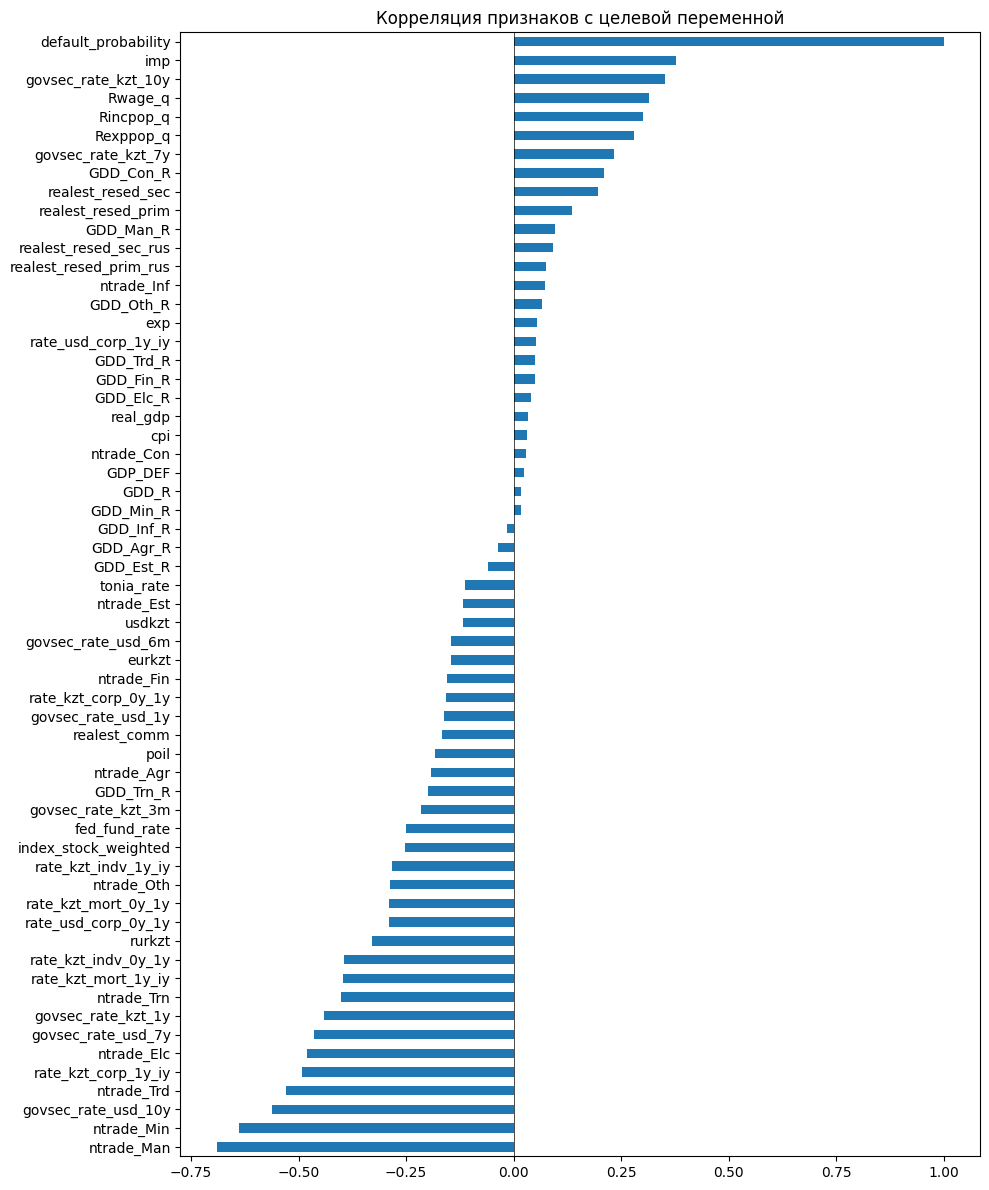

In [178]:
final_dataset.drop(columns=['quarter','macroparameter']).corr()['default_probability'].sort_values().plot(
    kind='barh', figsize=(10, 12)
)
plt.title('Корреляция признаков с целевой переменной')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

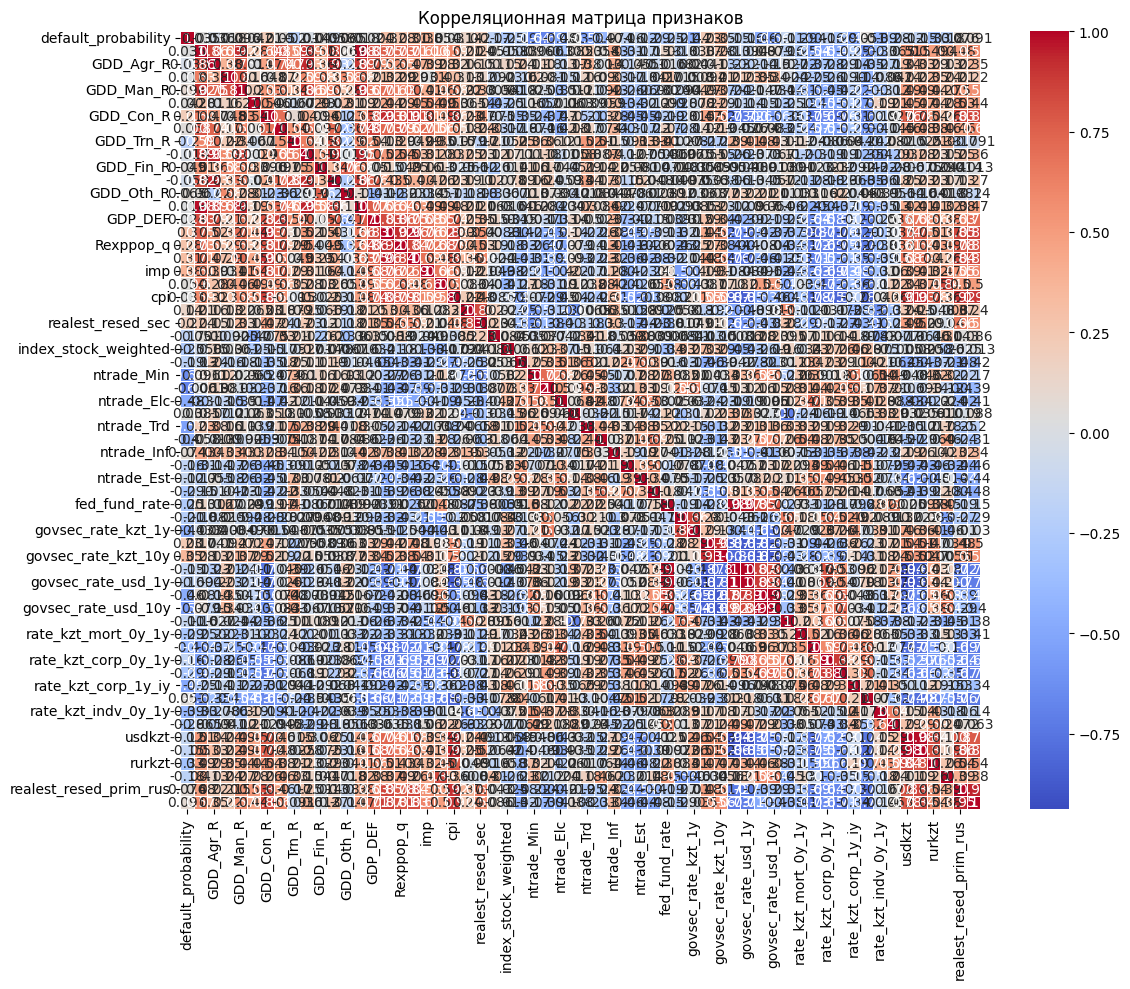

In [179]:
plt.figure(figsize=(12, 10))
correlation_matrix = (final_dataset.drop(columns=['quarter','macroparameter'])
                     .corr()
                    )
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

# Очистка от NAN

In [211]:
final_dataset.isna().sum()

quarter                   0
default_probability       0
macroparameter            0
real_gdp                  0
GDD_Agr_R                 0
GDD_Min_R                 0
GDD_Man_R                 0
GDD_Elc_R                 0
GDD_Con_R                 0
GDD_Trd_R                 0
GDD_Trn_R                 0
GDD_Inf_R                 0
GDD_Fin_R                 0
GDD_Est_R                 0
GDD_Oth_R                 0
GDD_R                     0
GDP_DEF                   0
Rincpop_q                 0
Rexppop_q                 0
Rwage_q                   0
imp                       0
exp                       0
cpi                       0
realest_resed_prim        0
realest_resed_sec         0
realest_comm              0
index_stock_weighted      0
ntrade_Agr                0
ntrade_Min                0
ntrade_Man                0
ntrade_Elc                0
ntrade_Con                0
ntrade_Trd                0
ntrade_Trn                0
ntrade_Inf                0
ntrade_Fin          

In [208]:
final_dataset[final_dataset.columns[3:]] = final_dataset[final_dataset.columns[3:]].apply(pd.to_numeric, errors='ignore')

C:\Users\Салтанат\AppData\Local\Temp\ipykernel_13360\4293468431.py:1: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  final_dataset[final_dataset.columns[3:]] = final_dataset[final_dataset.columns[3:]].apply(pd.to_numeric, errors='ignore')


In [209]:
final_dataset = final_dataset.fillna(final_dataset.mean(numeric_only=True))

# BaseLine

In [212]:
X = final_dataset.drop(columns=['quarter','macroparameter','default_probability'])
y = final_dataset['default_probability']

In [216]:
preprocessor = (
    ColumnTransformer(
        transformers=[("num", StandardScaler(), X.columns)],
        remainder="drop",
        n_jobs=-1,
    )
)


In [214]:
random_state = 42
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=random_state,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=random_state
)

In [220]:
params_LinearRegression = {
    "fit_intercept": True
}
model = LinearRegression(**params_LinearRegression)
pipeline = Pipeline(steps=[('preprocessor', preprocessor),("model", model)])
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse 

In [222]:
prediction = pipeline.predict(X_test)

In [ ]:
def train_and_log(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    RUN_NAME,
    EXPERIMENT_NAME,
    REGISTRY_MODEL_NAME,
    metadata,
):
    """
    Обучает модель, вычисляет метрики, логирует в mlflow и вычисляет метрики.
    """
    # Запускаем обучение модели
    model.fit(X_train, y_train)

    eval_data = X_test.copy()
    eval_data["label"] = y_test

    experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

    if experiment is None:
        experiment_id = mlflow.create_experiment(EXPERIMENT_NAME)
    else:
        experiment_id = experiment.experiment_id

    with mlflow.start_run(run_name=RUN_NAME, experiment_id=experiment_id):

        mlflow.log_params(model.named_steps["model"].get_params())
        # Предсказания
        y_pred = model.predict(X_test)
        signature = infer_signature(X_test, y_pred)
        input_example = X_test[:10]
        pip_requirements = "requirements.txt"

        model_info = mlflow.sklearn.log_model(
            sk_model=pipeline,
            name="dr_pipeline",
            registered_model_name=REGISTRY_MODEL_NAME,
            metadata=metadata,
            signature=signature,
            input_example=input_example,
            pip_requirements=pip_requirements,
            await_registration_for=60,
        )
        result = evaluate(
            model_info.model_uri,
            eval_data,
            targets="label",
            model_type="regressor",
            evaluator_config={"log_explainer": True},
        )

        for artifact_name in result.artifacts:
            if "shap" in artifact_name.lower():
                print(f"Generated: {artifact_name}")


In [249]:
metadata = {
    "model_type": "regression",
    "model_class": "LinearRegression",
    "features": "macro_factors",
    "notes": "baseline model, no feature selection yet",
    "status": "experimental",
}
EXPERIMENT_NAME = "dr_macro_regression"
RUN_NAME = "baseline_all_features"
REGISTRY_MODEL_NAME = "dr_macro_model"

train_and_log(
    model=pipeline,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    RUN_NAME=RUN_NAME,
    EXPERIMENT_NAME=EXPERIMENT_NAME,
    REGISTRY_MODEL_NAME=REGISTRY_MODEL_NAME,
    metadata=metadata,
)


2026/04/22 23:54:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'dr_macro_model' already exists. Creating a new version of this model...
2026/04/22 23:54:25 INFO mlflow.store.model_registry.abstract_store: Waiting up to 60 seconds for model version to finish creation. Model name: dr_macro_model, version 2
Created version '2' of model 'dr_macro_model'.


2026/04/22 23:54:28 INFO mlflow.tracking.fluent: Active model is set to the logged model with ID: m-9c1d84f70ca34de386d3163b18df49ef
2026/04/22 23:54:28 INFO mlflow.tracking.fluent: Use `mlflow.set_active_model` to set the active model to a different one if needed.
2026/04/22 23:54:34 INFO mlflow.models.evaluation.utils.trace: Auto tracing is temporarily enabled during the model evaluation for computing some metrics and debugging. To disable tracing, call `mlflow.autolog(disable=True)`.
2026/04/22 23:56:10 INFO mlflow.models.evaluation.default_evaluator: Testing metrics on first row...
2026/04/22 23:57:07 INFO mlflow.models.evaluation.evaluators.shap: Shap explainer PermutationExplainer is used.
PermutationExplainer explainer: 6it [02:28, 29.74s/it]                       
c:\Users\Салтанат\Documents\Учеба в Яндексе\tests\.venv\Lib\site-packages\mlflow\shap\__init__.py:454: UserWarning: Unable to serialize underlying model using MLflow, will use SHAP serialization
  warnings.warn(
c:\Us

Generated: shap_beeswarm_plot
Generated: shap_summary_plot
Generated: shap_feature_importance_plot
🏃 View run baseline_all_features at: http://127.0.0.1:5000/#/experiments/1/runs/c1ad30214fe944748b06c19b4b71f34d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
